## Resonator Fitting 
Luke Wanner, Colorado School of Mines

Based on the resonator fitting scheme in appendix E of Jiansong Gao's Cal Tech thesis. This first fits to the circle and the phase data to find the initial parameters then uses these as initial guesses for the full least-squares fitting. This follws the scheme in Ben Mates' scripts (NIST_resonators_BenMates), with added least squares fitting. 


The two relevent scripts are:

- circle_fitting.py
- resonance_fitting.py

In [1]:

import numpy as np
import scipy as sp
from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar
from resonator_fitting.include import lambdafit as lf
import time
import matplotlib.pyplot as plt


plt.ion()

filename = "frsurvey_umux1M_v2_(0,7)W0_Band06_20251201.npz"

###########################################################################################
# When we take a flux-ramp survey we should save at least the following variables:
#   f_wide      : Frequencies in wide VNA sweep (Hz).                           (l)
#   s21_wide    : Complex S21 values from wide VNA sweep.                       (l)
#   fc          : Center frequencies for the flux-ramp survey (Hz).             (n)
#   ibias       : Bias current values applied to the flux-ramp coil (A).        (m)
#   fbias       : Frequency offsets in VNA sweeps for flux-ramp survey (Hz).    (p)
#   s21_fr      : Complex S21 values from flux-ramp survey sweeps.          (n x m x p)
data = np.load(filename)
f_wide = data['f_wide']
s21_wide = data['s21_wide']
fc = data['fc']
ibias = data['ibias']
fbias = data['fbias']
s21_fr = data['s21_fr']
tau = data['tau']

Narrow into one resonator

In [2]:
print(tau)

4.835517431552468e-08


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


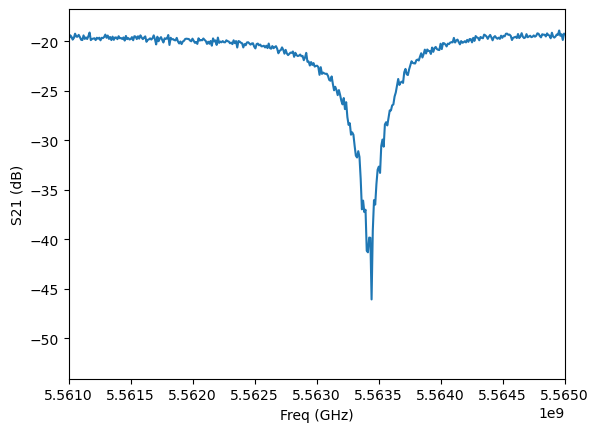

In [3]:
f_min = 5.561e9
f_max = 5.565e9

plt.plot(f_wide, 20*np.log10(s21_wide))
plt.xlim((f_min, f_max))
plt.ylabel("S21 (dB)")
plt.xlabel("Freq (GHz)")

mask = (f_wide >= f_min) & (f_wide <= f_max)
f_region = f_wide[mask]
s21_region = s21_wide[mask]
data_to_save = np.column_stack((f_region,s21_region))
np.savetxt('../../uMux_modeling/resonance_sweep.txt', data_to_save, header='Frequency(Hz) S21_Mag(dB)')




In [4]:
print(f_max-f_min)

4000000.0


Fit successful! Resonance Frequency: 5.563457 +/- 0.000003 GHz


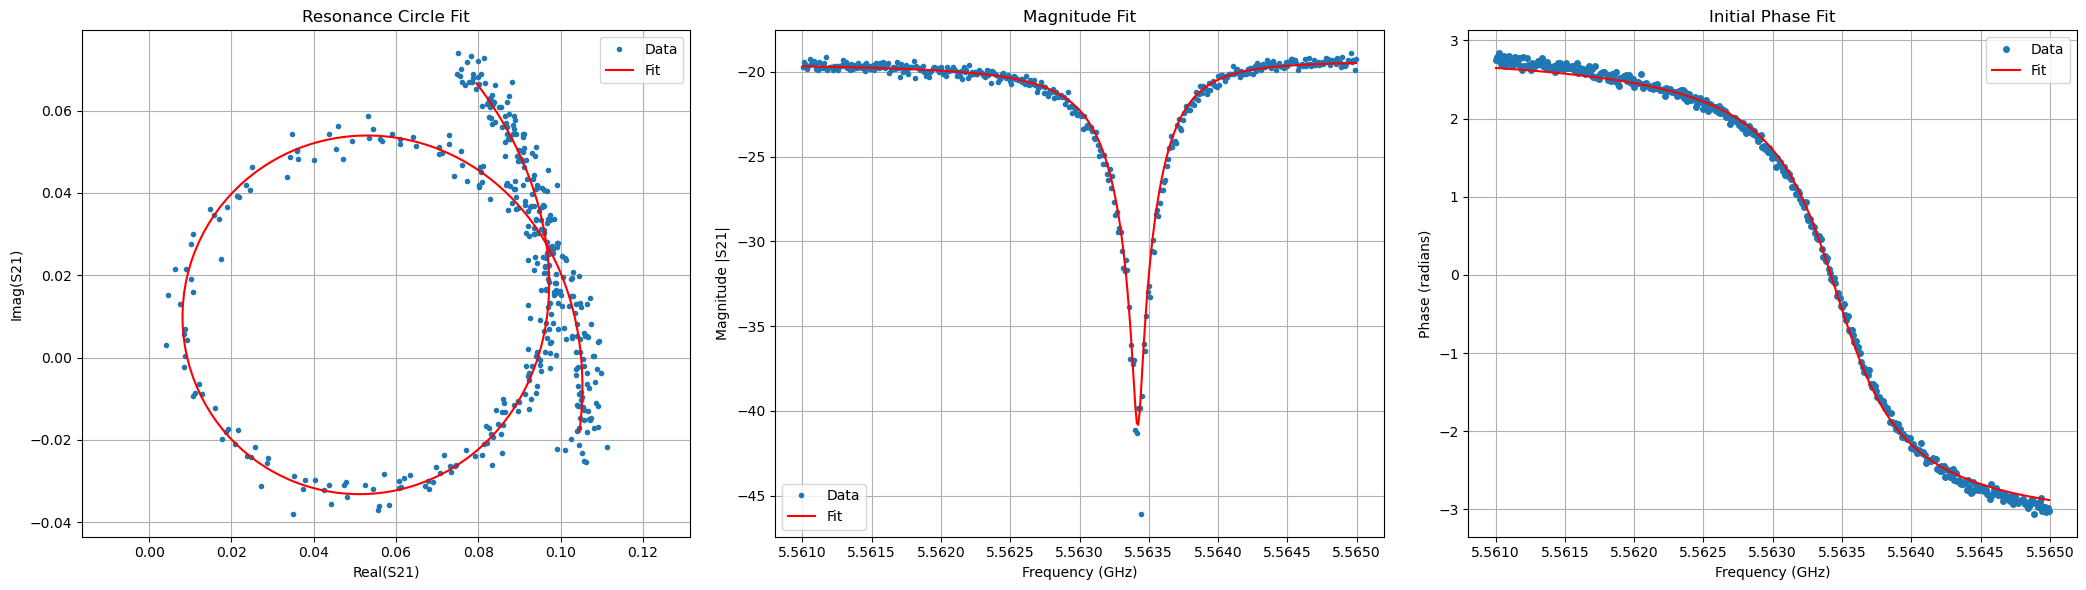

0.10644212015896184 4.8348786145856204e-08 5563456526.541238 7704.664550738133 8372.215718895728 -0.10992592942779858 1.5286660548264166


In [5]:


a_fine, tau_fine, fr_fine, Qr_fine, Qc_fine, phi0_fine, chi2 = rf.refined_fit(f_region, s21_region, tau, plot_mode='condensed', filename = None)
print(a_fine, tau_fine, fr_fine, Qr_fine, Qc_fine, phi0_fine, chi2)





Text(0.5, 0, 'Freq (GHz)')

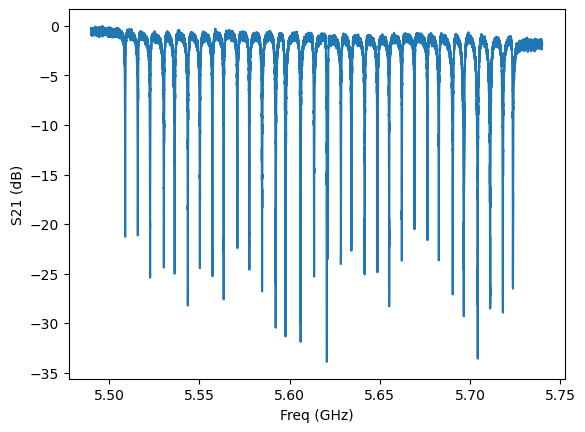

In [6]:
f_start = 5.45e9
f_stop = 5.57e9

f_range = f_stop-f_start

# mask = (f_wide >= f_start) & (f_wide <= f_stop)
# f = f_wide[mask]
# s21 = s21_wide[mask]
f = f_wide
s21 = s21_wide
s21_logmag = 20*np.log10(np.abs(s21)) - np.max(20*np.log10(np.abs(s21)))

data_to_save = np.column_stack((f,s21))
np.savetxt('../../uMux_modeling/NIST_full_s21.txt', data_to_save, header='Frequency(Hz) S21_Mag(dB)')

plt.plot(f*1e-9, s21_logmag)

plt.ylabel("S21 (dB)")
plt.xlabel("Freq (GHz)")



/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


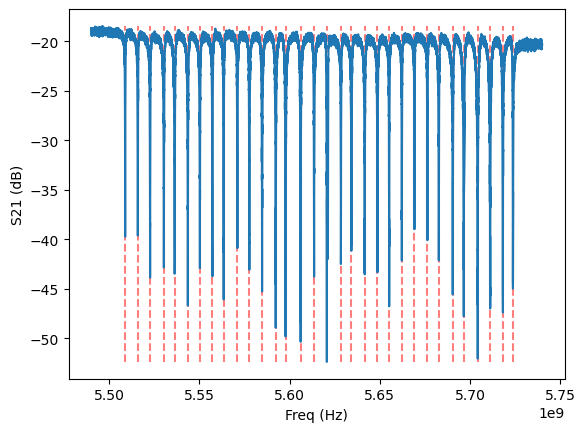

--- Resonator Analysis ---
Number of resonators: 32
Average frequency: 5.6168 GHz
Average spacing (filtered < 10 MHz): 6.93 MHz



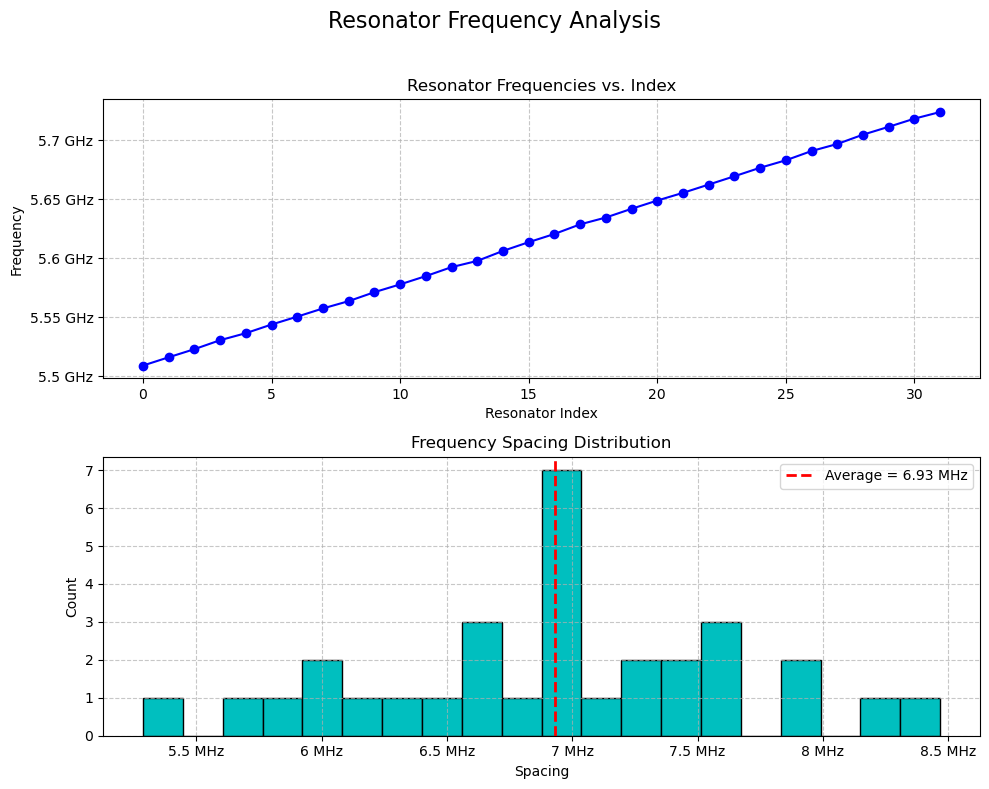

--- Bandwidth Analysis ---
Number of resonators: 32
Average bandwidth: 979.66 kHz


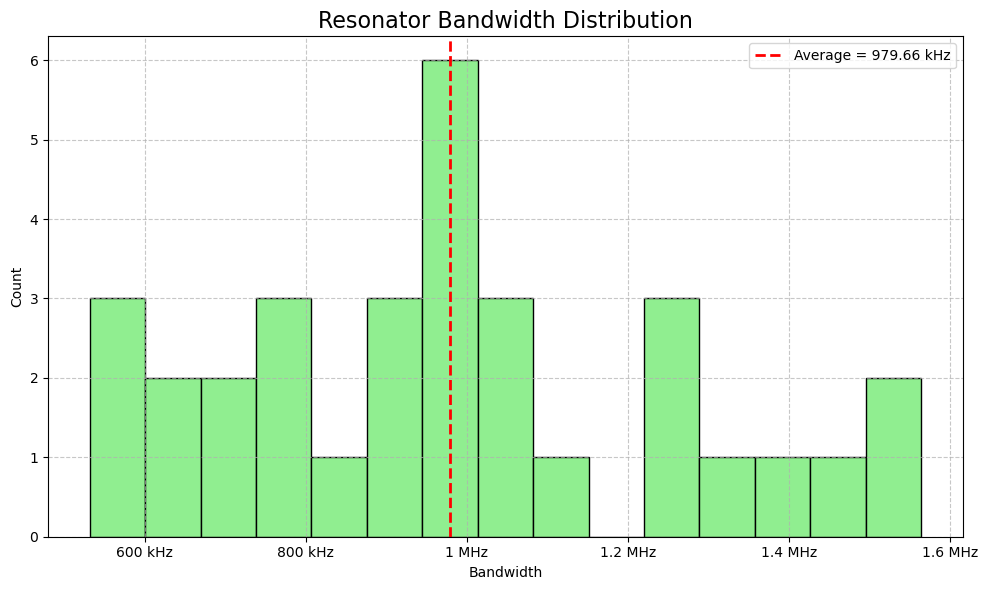

--- Q Factor Analysis ---
Average Coupling Q (Qc): 6,568
Average Internal Q (Qi): 70,656
Average Loaded Q (Qr):   6,207



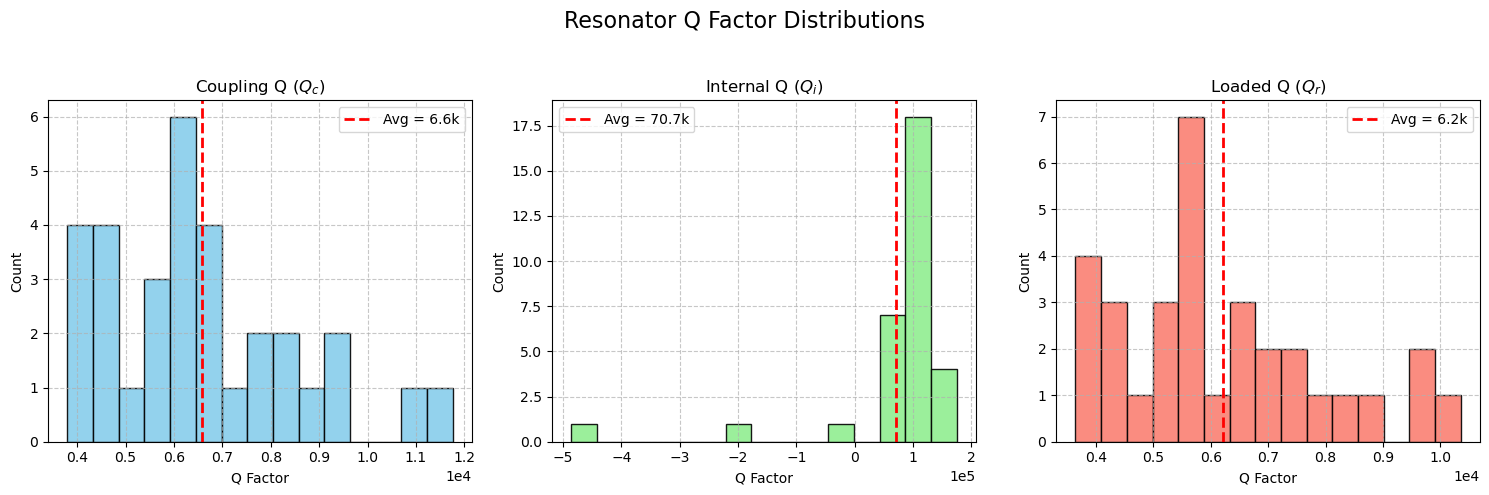

--- Chi-Squared Analysis ---
Number of fits: 32
Average Chi-Squared: 2.35
Std. Dev. of Chi-Squared: 2.07



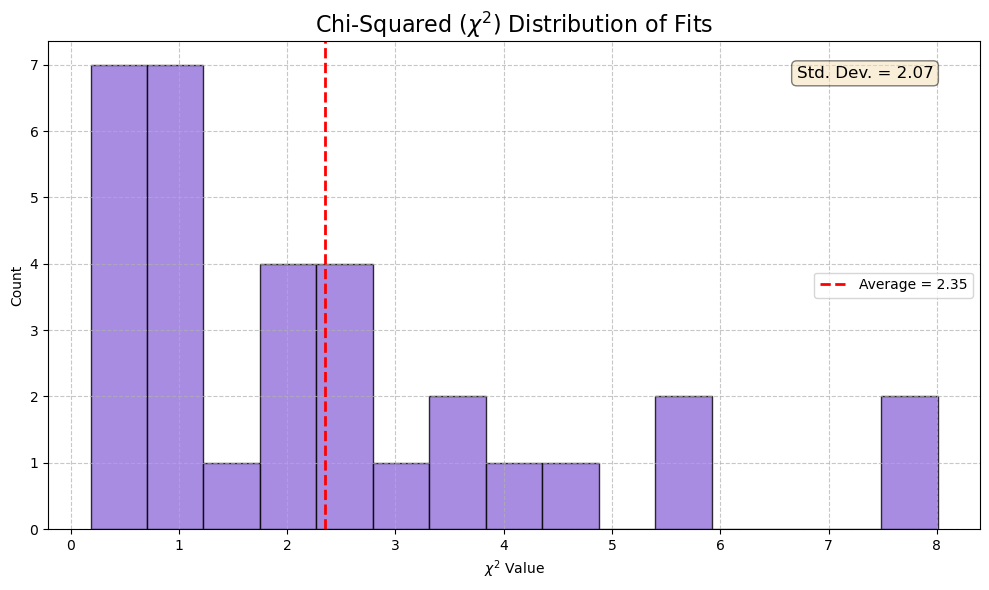

In [7]:
aas, taus, frs, Qrs, Qcs, Qis, bws, phi0s, chi2s = ar.fit_all_resonators(f, s21, tau, showplot=True, filename="NIST_umux_all")
data_to_save = np.column_stack((aas, taus, frs, Qrs, Qcs, Qis, bws, phi0s, chi2s))
np.savetxt('../../uMux_modeling/NIST_full_params.txt', data_to_save, header='aas taus frs Qrs Qcs Qis bws phi0s chi2s')


Mc = 2.927037809434641e-08
Min = 1.442368024401512e-11
Mc = 2.7642294955451386e-08
Min = 1.4398615031091238e-11
Mc = 2.918645626842623e-08
Min = 1.4354760430553397e-11
Mc = 9.819418294719639e-08
Min = 1.4471363906585474e-11
Mc = 5.62317225297008e-08
Min = 1.4380285450975777e-11
Mc = 5.873267135317775e-08
Min = 1.4414259574404308e-11
Mc = 9.95817584385906e-08
Min = 1.4384717477133294e-11
Mc = 6.033298333965377e-08
Min = 1.433438853664244e-11
Mc = 6.366963748626674e-07
Min = 1.4387587826300946e-11
Mc = 9.730061412465928e-08
Min = 1.437049128909209e-11
Mc = 8.878014396109334e-08
Min = 1.441559830635344e-11
Mc = 7.980418105444028e-08
Min = 1.4373593784206328e-11
Mc = 5.625501730632903e-08
Min = 1.4439435525921102e-11
Mc = 2.7335541796040502e-08
Min = 1.436588873335544e-11
Mc = 5.1128905538592914e-08
Min = 1.4401806227613059e-11
Mc = 5.34071558308979e-08
Min = 1.4413295031976538e-11
Mc = 7.160240984863639e-08
Min = 1.4241585118040707e-11
Mc = 5.297264710745072e-08
Min = 1.4394991504698857e-

/var/folders/5y/0rp23b8505l125t55yv9lq140000gn/T/ipykernel_71450/3600064567.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


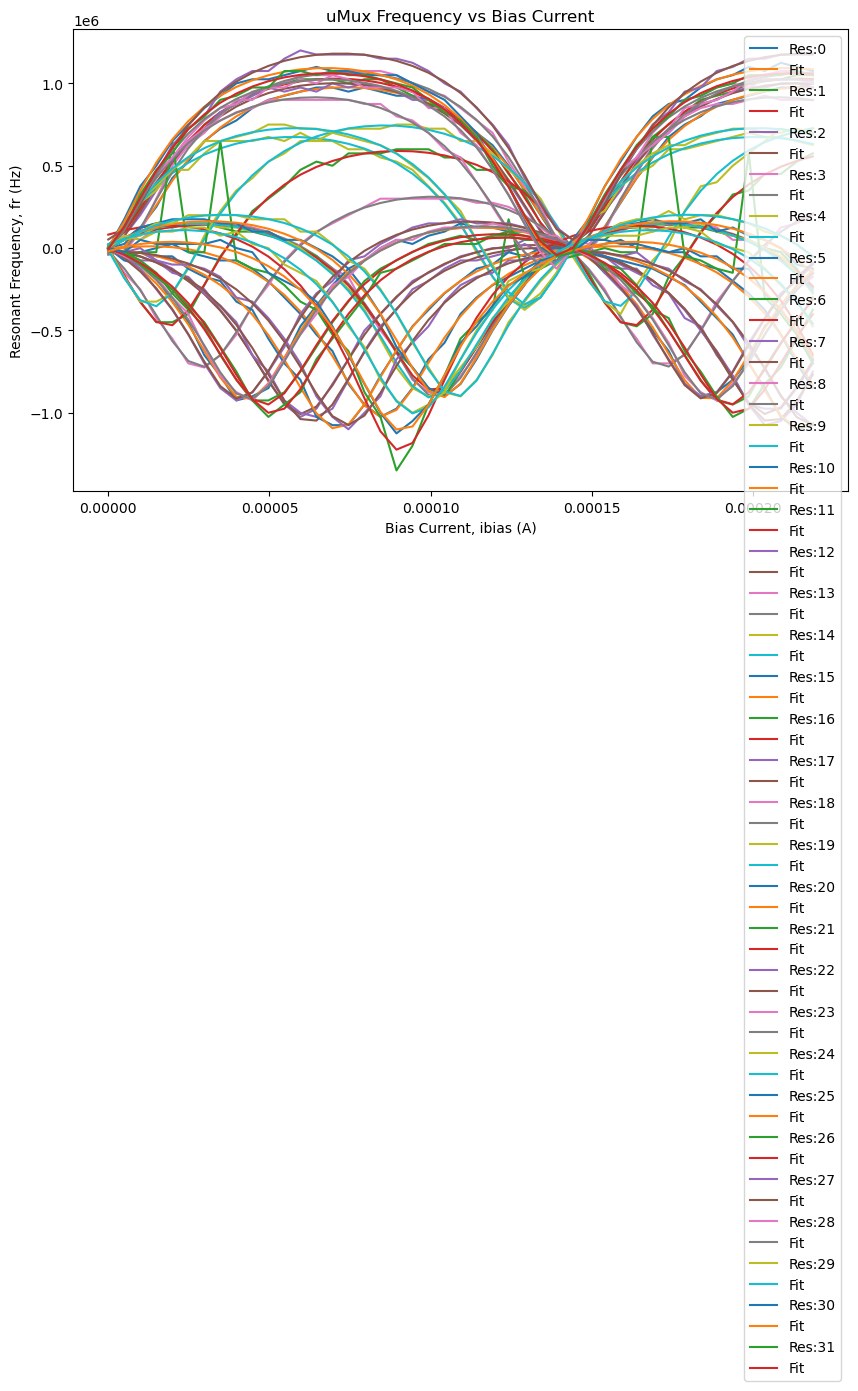

In [ ]:

min_idx = np.argmin(np.abs(s21_fr), axis=2)

frs = fc[:, np.newaxis] + fbias[min_idx]

plt.figure(figsize=(10, 6))

plt.xlabel("Bias Current, ibias (A)")
plt.ylabel("Resonant Frequency, fr (Hz)")
plt.title("uMux Frequency vs Bias Current")

dfs = frs - frs[:, 0:1] 
bad_resonator = 16

I0fits = np.empty(0)
Minfits = np.empty(0)
Mcfits = np.empty(0)
fbfits = np.empty(0)
lambfits = np.empty(0)


for i in range(32):
    plt.plot(ibias, dfs[i] , label = "Res:"+str(i))
    I0fit,Minfit,Mcfit,fbfit,lambfit = lf.fit_lambda(ibias, dfs[i])
    I0fits = np.append(I0fits,I0fit)
    Minfits = np.append(Minfits,Minfit)
    Mcfits = np.append(Mcfits,Mcfit)
    fbfits = np.append(fbfits,fbfit)
    lambfits = np.append(lambfits,lambfit)
    print("Mc =",Mcfit)
    print("Min =",Minfit)
    f0_fit = lf.f0_of_I(ibias,I0fit,Minfit,Mcfit,fbfit,lambfit)
    plt.plot(ibias, f0_fit, label="Fit")     
           
plt.legend()
plt.tight_layout()
plt.show()

freqs = dfs

np.savez('../../uMux_modeling/data/measured_flux_response.npz',
         ibias = ibias, 
         freqs = freqs)
        
np.savez('../../uMux_modeling/data/flux_response_params.npz', 
         ibias=ibias, 
         I0fits=I0fits, 
         Minfits=Minfits, 
         Mcfits=Mcfits, 
         fbfits=fbfits, 
         lambfits=lambfits)